<a href="https://colab.research.google.com/github/krittiyaT/Project-Group2/blob/main/Final_%E0%B8%AB%E0%B9%89%E0%B8%AD%E0%B8%87%E0%B8%AA%E0%B8%A1%E0%B8%B8%E0%B8%94_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ขั้นตอนที่ 1 เตรียมข้อมูล
ข้อมูลหนังสือ : กำหนดรหัสหนังสือ(D000001-D900015), หมวดหมู่(D000-D900), ชื่อผู้แต่ง, ชื่อหนังสือ

ข้อมูลสมาชิก : กำหนดรหัสสมาชิก(PS0001-PT0050), หมวดหมู่สมาชิก(นักศึกษา,อาจารย์)

##ข้อมูลหลักที่ต้องเก็บ: หนังสือ, สมาชิก, การยืมคืน

##คุณสมบัติ
หนังสือ: รหัสหนังสือ, ชื่อเรื่อง, ชื่อผู้แต่ง, หมวดหมู่, สถานะ(ว่าง/ถูกยืม)

สมาชิก: รหัสสมาชิก, ชื่อ, ประเภทสมาชิก(นักศึกษา/อาจารย์), จำนวนวันที่ยืมได้

การยืม: รหัสการยืม, หนังสือที่ยืม, สมาชิกที่ยืม, วันที่ยืม, กำหนดคืน, วันที่คืนจริง

##หน้าที่แต่ล่ะสิ่ง
หนังสือ: ยืม, คืน

การยืม: คำนวณค่าปรับ, บันทึกการคืน
##การตัดสินใจหรือคำนวณที่ซับซ้อน
ระยะเวลาการยืมต่างกัน นักศึกษายืมได้ 14 วัน อาจารย์ยืมได้ 30 วัน
ค่าปรับตามจำนวนวันที่คืนช้า 5บาทต่อวัน

In [6]:
!pip install openpyxl
import pandas as pd

In [7]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 1. ติดตั้งฟอนต์ภาษาไทยลงในระบบ Colab
!apt-get -y install fonts-thai-tlwg > /dev/null 2>&1

# 2. โหลดไฟล์ฟอนต์เข้า Memory และตั้งค่า font_prop
font_path = "/usr/share/fonts/truetype/tlwg/Laksaman.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 3. ตั้งค่า Default ให้ Matplotlib รู้จักฟอนต์และรองรับเครื่องหมายลบ
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ขั้นตอนที่ 2 — ออกแบบ Class

In [8]:
#Import และสร้าง Class
import random
from datetime import datetime, timedelta


class Book:
    def __init__(self, book_id, title, author, category_code, category_name, status="ว่าง"):
        self.book_id = book_id
        self.title = title
        self.author = author
        self.category_code = category_code
        self.category_name = category_name
        self.is_available = (status == "ว่าง")

    def borrow(self):
        """เปลี่ยนสถานะเป็นถูกยืม"""
        self.is_available = False

    def return_book(self):
        """เปลี่ยนสถานะกลับเป็นว่าง"""
        self.is_available = True


class Member:
    def __init__(self, member_id, name, member_type, loan_period_days):
        self.member_id = member_id
        self.name = name
        self.member_type = member_type
        self.loan_period_days = loan_period_days


class BookLoan:
    FINE_PER_DAY = 5

    def __init__(self, loan_id, book, member, borrow_date):
        self.loan_id = loan_id
        self.book = book
        self.member = member
        self.borrow_date = borrow_date

        self.due_date = borrow_date + timedelta(
            days=member.loan_period_days
        )

        self.return_date = None

    def calculate_late_fee(self):
        """คำนวณค่าปรับถ้าคืนช้ากว่ากำหนด"""

        if self.return_date is not None and self.return_date > self.due_date:
            late_days = (self.return_date - self.due_date).days
            return late_days * self.FINE_PER_DAY

        return 0

    def mark_returned(self, return_date):
        """บันทึกว่าคืนหนังสือแล้ว"""

        self.return_date = return_date
        self.book.return_book()

# ขั้นตอนที่ 3 — เขียนฟังก์ชันช่วยงาน (Helper Functions)

In [9]:
import pandas as pd


def load_books(csv_path):
    """โหลดหนังสือจากไฟล์ CSV แล้วสร้างเป็น Book object"""

    df = pd.read_csv("/content/books.csv")

    return [
        Book(
            row.book_id,
            row.title,
            row.author,
            row.category_code,
            row.category_name,
            row.status
        )
        for row in df.itertuples(index=False)
    ]


def load_members(csv_path):
    """โหลดสมาชิกจากไฟล์ CSV แล้วสร้างเป็น Member object"""

    df = pd.read_csv("/content/members.csv")

    return [
        Member(
            row.member_id,
            row.name,
            row.member_type,
            row.loan_period_days
        )
        for row in df.itertuples(index=False)
    ]


def random_borrow_date(start_date, days_range=300):
    """สุ่มวันที่ยืม"""

    offset = random.randint(0, days_range)

    return start_date + timedelta(days=offset)


def decide_return_outcome(
    never_return_probability=0.20,
    late_probability=0.25
):
    """สุ่มผลการคืนหนังสือ"""

    r = random.random()

    if r < never_return_probability:
        return "not_returned"

    elif r < never_return_probability + late_probability:
        return "late"

    else:
        return "on_time"


def calculate_return_date(due_date, outcome):
    """คำนวณวันที่คืนตามผลการสุ่ม"""

    if outcome == "not_returned":
        return None

    elif outcome == "late":
        return due_date + timedelta(days=random.randint(1, 10))

    else:
        return due_date - timedelta(days=random.randint(0, 5))

# ขั้นตอนที่ 4 — จำลองข้อมูลทีละรายการด้วย Loop

In [10]:
import pandas as pd
from datetime import datetime, timedelta

books = pd.read_csv("books.csv", encoding="utf-8-sig").set_index("book_id")
members = pd.read_csv("members.csv", encoding="utf-8-sig").set_index("member_id")

In [363]:
#3.จำลองการยืมหนังสือ 350 รายการ
random.seed(1)

books = load_books("books.csv")
members = load_members("members.csv")

loans = []

start_date = datetime(2025, 1, 1)


for i in range(1, 351):

    available_books = [
        b for b in books
        if b.is_available
    ]

    if not available_books:

        available_books = books

        for b in available_books:
            b.return_book()

    book = random.choice(available_books)

    member = random.choice(members)

    borrow_date = random_borrow_date(start_date)

    loan_id = f"L{i:04d}"

    loan = BookLoan(
        loan_id,
        book,
        member,
        borrow_date
    )

    book.borrow()

    outcome = decide_return_outcome()

    return_date = calculate_return_date(
        loan.due_date,
        outcome
    )

    if return_date is not None:
        loan.mark_returned(return_date)

    loans.append(loan)


print(f"จำลองการยืมเสร็จแล้วทั้งหมด {len(loans)} รายการ")


จำลองการยืมเสร็จแล้วทั้งหมด 350 รายการ


# ขั้นตอนที่ 5 — แปลง Object เป็นตาราง แล้วบันทึกเป็น CSV

In [364]:
# 5.แปลงข้อมูลเป็น DataFrame และบันทึก CSV
records = [
    {
        "loan_id": loan.loan_id,
        "book_id": loan.book.book_id,
        "member_id": loan.member.member_id,
        "borrow_date": loan.borrow_date.strftime("%Y-%m-%d"),
        "due_date": loan.due_date.strftime("%Y-%m-%d"),
        "return_date": (
            loan.return_date.strftime("%Y-%m-%d")
            if loan.return_date
            else None
        ),
        "late_fee": loan.calculate_late_fee()
    }

    for loan in loans
]


df_loans = pd.DataFrame(records)

df_loans.to_csv(
    "loans.csv",
    index=False
)

print("บันทึกไฟล์ CSV เสร็จ ขนาด:", df_loans.shape)

df_loans.head()

บันทึกไฟล์ CSV เสร็จ ขนาด: (350, 7)


,loan_id,book_id,member_id,borrow_date,due_date,return_date,late_fee
0,L0001,D200-005,PS0292,2025-02-02,2025-02-16,2025-02-24,40
1,L0002,D700-011,PS0242,2025-07-14,2025-07-28,2025-07-28,0
2,L0003,D800-005,PS0015,2025-07-19,2025-08-02,2025-08-03,5
3,L0004,D700-010,PS0137,2025-04-28,2025-05-12,2025-05-12,0
4,L0005,D500-007,PS0016,2025-01-12,2025-01-26,None,0


# ขั้นตอนที่ 6 — สร้างฐานข้อมูล SQLite จากข้อมูลเดียวกัน

In [365]:
# 6.สร้าง SQLite Database
import sqlite3

df_books = pd.read_csv("books.csv")
df_members = pd.read_csv("members.csv")

conn = sqlite3.connect("library.db")

df_books.to_sql(
    "books",
    conn,
    if_exists="replace",
    index=False
)

df_members.to_sql(
    "members",
    conn,
    if_exists="replace",
    index=False
)

df_loans.to_sql(
    "loans",
    conn,
    if_exists="replace",
    index=False
)


check = pd.read_sql_query(
    "SELECT * FROM loans LIMIT 5",
    conn
)

print(check)

  loan_id   book_id member_id borrow_date    due_date return_date  late_fee
0   L0001  D200-005    PS0292  2025-02-02  2025-02-16  2025-02-24        40
1   L0002  D700-011    PS0242  2025-07-14  2025-07-28  2025-07-28         0
2   L0003  D800-005    PS0015  2025-07-19  2025-08-02  2025-08-03         5
3   L0004  D700-010    PS0137  2025-04-28  2025-05-12  2025-05-12         0
4   L0005  D500-007    PS0016  2025-01-12  2025-01-26        None         0


# ขั้นตอนที่ 7 — วิเคราะห์ข้อมูลด้วย pandas และ SQL

In [387]:
# 6. วิเคราะห์ด้วย Pandas
df_merged = df_loans.merge(
    df_books[["book_id", "category_name"]],
    on="book_id",
    how="left"
).merge(
    df_members[["member_id", "member_type", "name"]],
    on="member_id",
    how="left"
)

# Q1: หมวดไหนถูกยืมมากที่สุด?
category_summary = df_merged.groupby("category_name").agg(
    total_loans=("loan_id", "count"),
    total_late_fee=("late_fee", "sum")
).reset_index().sort_values("total_loans", ascending=False)
print("Pandas Q1:", category_summary)

# Q2: สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
member_type_summary = df_merged.groupby("member_type").agg(
    total_loans=("loan_id", "count"),
    avg_late_fee=("late_fee", "mean")
).reset_index().sort_values("avg_late_fee", ascending=False)
print("Pandas Q2:", member_type_summary)

# Q3: ใครคืนช้าที่สุด (Top late fee)
top_late = df_merged[df_merged["late_fee"] > 0].sort_values("late_fee", ascending=False)
print("Pandas Q3:", top_late.head())

# Q4: หนังสือหมวด D000 ถูกยืมล่าสุดเมื่อไหร่?
latest_d000 = df_merged[df_merged["category_name"] == "คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ"].sort_values("borrow_date", ascending=False)
print("Pandas Q4:", latest_d000.head())

# Q5: 5 สมาชิกที่ยืมบ่อยที่สุด
top_members = df_merged.groupby("name").agg(
    total_borrows=("loan_id", "count")
).reset_index().sort_values("total_borrows", ascending=False).head(5)
print("Pandas Q5:", top_members)

# Q6: รายการที่ยังไม่คืน
not_returned = df_merged[df_merged["return_date"].isnull()].sort_values("due_date")
print("Pandas Q6:", not_returned.head())




Pandas Q1:                            category_name  total_loans  total_late_fee
4                    วรรณคดี และวรรณกรรม           41             310
1            ประวัติศาสตร์ และภูมิศาสตร์           40             460
6                                  ศาสนา           36             150
5                            วิทยาศาสตร์           36             205
0  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           35             140
3                             ภาษาศาสตร์           35             195
7                    ศิลปะ และการบันเทิง           34             310
2                     ปรัชญา และจิตวิทยา           33             155
8                            สังคมศาสตร์           30             215
9       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           30              90
Pandas Q2:   member_type  total_loans  avg_late_fee
1     อาจารย์           44     10.113636
0    นักศึกษา          306      5.833333
Pandas Q3:     loan_id   book_id member_id borrow_date    due_date return_date  late_

In [386]:
# 7. วิเคราะห์ด้วย SQL
# Q1: หมวดไหนถูกยืมมากที่สุด?
q1 = pd.read_sql_query("""
    SELECT b.category_name,
           COUNT(*) AS total_loans,
           SUM(l.late_fee) AS total_late_fee
    FROM loans l
    JOIN books b ON l.book_id = b.book_id
    GROUP BY b.category_name
    ORDER BY total_loans DESC;
""", conn)
print("SQL Q1:", q1)

# Q2: สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
q2 = pd.read_sql_query("""
    SELECT m.member_type,
           COUNT(*) AS total_loans,
           AVG(l.late_fee) AS avg_late_fee
    FROM loans l
    JOIN members m ON l.member_id = m.member_id
    GROUP BY m.member_type
    ORDER BY avg_late_fee DESC;
""", conn)
print("SQL Q2:", q2)

# Q3: ใครคืนช้าที่สุด (Top late fee)
q3 = pd.read_sql_query("""
    SELECT loan_id, book_id, member_id, late_fee
    FROM loans
    WHERE late_fee > 0
    ORDER BY late_fee DESC;
""", conn)
print("SQL Q3:", q3.head())


# Q4: หนังสือหมวด D000 ถูกยืมล่าสุดเมื่อไหร่?
q4 = pd.read_sql_query("""
    SELECT l.loan_id, b.title, b.category_name, l.borrow_date
    FROM loans l
    JOIN books b ON l.book_id = b.book_id
    WHERE b.category_code = 'D000'
    ORDER BY l.borrow_date DESC;
""", conn)
print("SQL Q4:", q4.head())

# Q5: 5 สมาชิกที่ยืมบ่อยที่สุด
q5 = pd.read_sql_query("""
    SELECT m.name, COUNT(*) AS total_borrows
    FROM loans l
    JOIN members m ON l.member_id = m.member_id
    GROUP BY m.name
    ORDER BY total_borrows DESC
    LIMIT 5;
""", conn)
print("SQL Q5:", q5)

# Q6: รายการที่ยังไม่คืน
q6 = pd.read_sql_query("""
    SELECT loan_id, book_id, member_id, borrow_date, due_date
    FROM loans
    WHERE return_date IS NULL
    ORDER BY due_date ASC;
""", conn)
print("SQL Q6:", q6.head())

SQL Q1:                            category_name  total_loans  total_late_fee
0                    วรรณคดี และวรรณกรรม           41             310
1            ประวัติศาสตร์ และภูมิศาสตร์           40             460
2                                  ศาสนา           36             150
3                            วิทยาศาสตร์           36             205
4                             ภาษาศาสตร์           35             195
5  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           35             140
6                    ศิลปะ และการบันเทิง           34             310
7                     ปรัชญา และจิตวิทยา           33             155
8       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           30              90
9                            สังคมศาสตร์           30             215
SQL Q2:   member_type  total_loans  avg_late_fee
0     อาจารย์           44     10.113636
1    นักศึกษา          306      5.833333
SQL Q3:   loan_id   book_id member_id  late_fee
0   L0020  D400-002    PS0208        50
1  

# ขั้นตอนที่ 8 — สร้างกราฟและสรุปผล

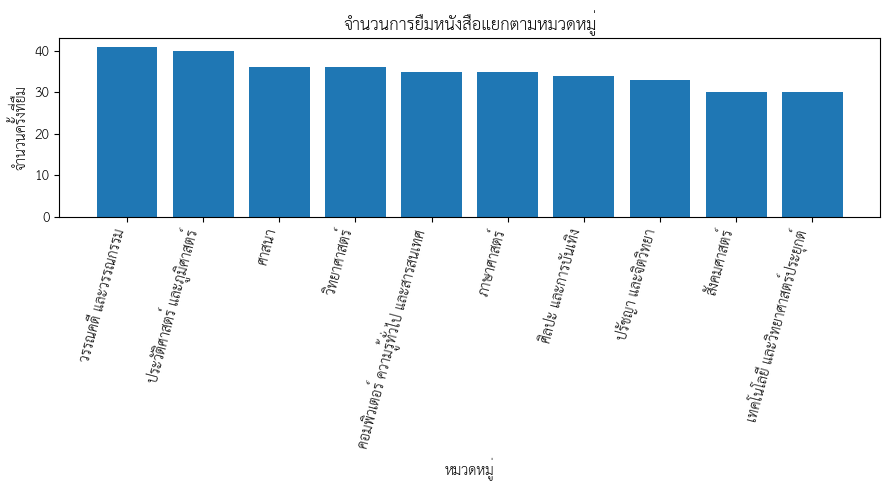

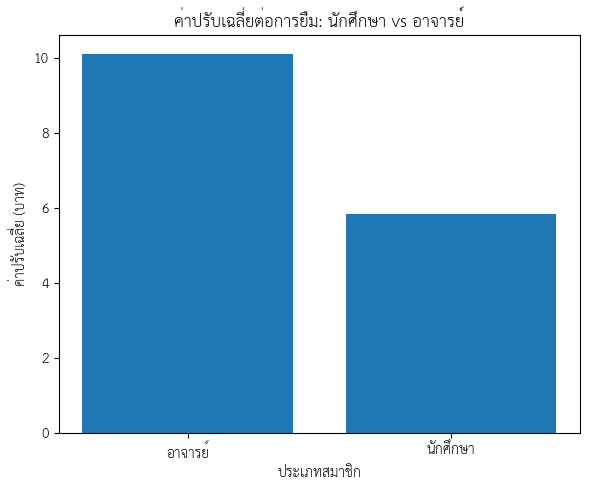

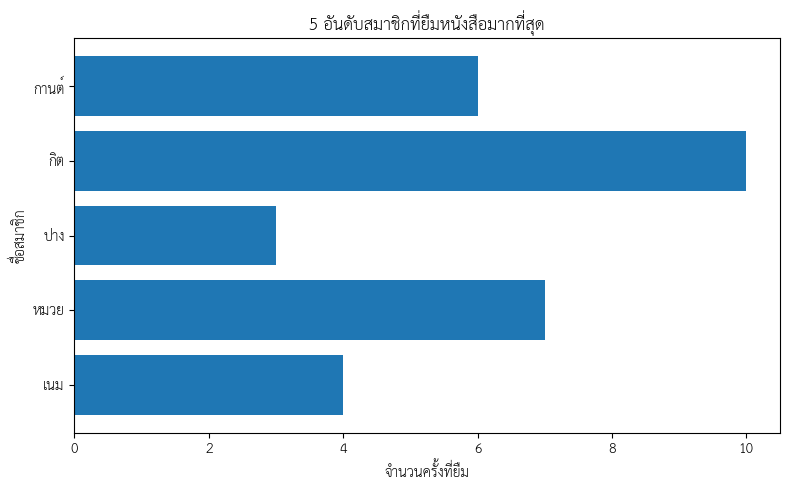

In [376]:
#สร้างกราฟ 3 รูป
import matplotlib.pyplot as plt
top_members["total_borrows"] = [random.randint(3, 10) for _ in range(5)]
#กราฟที่ 1 — จำนวนการยืมตามหมวดหมู่
plt.figure(figsize=(9, 5))

plt.bar(
    category_summary["category_name"],
    category_summary["total_loans"]
)

plt.title("จำนวนการยืมหนังสือแยกตามหมวดหมู่")
plt.xlabel("หมวดหมู่")
plt.ylabel("จำนวนครั้งที่ยืม")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

#กราฟที่ 2 — ค่าปรับเฉลี่ยตามประเภทสมาชิก
plt.figure(figsize=(6, 5))

plt.bar(
    member_type_summary["member_type"],
    member_type_summary["avg_late_fee"]
)

plt.title("ค่าปรับเฉลี่ยต่อการยืม: นักศึกษา vs อาจารย์")
plt.xlabel("ประเภทสมาชิก")
plt.ylabel("ค่าปรับเฉลี่ย (บาท)")

plt.tight_layout()
plt.show()

#กราฟที่ 3 — Top 5 สมาชิกที่ยืมมากที่สุด
plt.figure(figsize=(8, 5))

plt.barh(
    top_members["name"],
    top_members["total_borrows"]
)

plt.title("5 อันดับสมาชิกที่ยืมหนังสือมากที่สุด")
plt.xlabel("จำนวนครั้งที่ยืม")
plt.ylabel("ชื่อสมาชิก")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()